In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

from src.models import VAE
import matplotlib.pyplot as plt

from src.data_preprocessing import (
    read_oscilloscope_data, 
    segment_signal,
    normalize_segment,
    perform_fft_on_segments,
    plot_random_segments,
    plot_random_segments
)

In [2]:
def generate_induction_motor_signal(
    signal_length=1000,
    sampling_rate=1000,
    fundamental_freq=50,
    noise_scale=0.2,
    add_harmonics=True,
    add_spikes=True,
    add_noise=True,
    add_modulation=True
):
    """
    Generate a synthetic signal simulating induction motor current with selectable problems.
    
    Parameters:
        signal_length (int): Number of samples in the signal.
        sampling_rate (int): Sampling rate in Hz.
        fundamental_freq (float): Fundamental frequency in Hz.
        noise_scale (float): Standard deviation of Gaussian noise.
        add_harmonics (bool): If True, includes harmonic components.
        add_spikes (bool): If True, introduces transient spikes.
        add_noise (bool): If True, adds Gaussian noise.
        add_modulation (bool): If True, applies amplitude modulation.
    
    Returns:
        tuple: (clean_signal, noisy_signal)
            - clean_signal: The base signal without any disturbances.
            - noisy_signal: The signal with selected disturbances added.
    """
    np.random.seed(42)  # For reproducibility
    t = np.linspace(0, signal_length / sampling_rate, signal_length)
    
    # Fundamental signal
    fundamental = np.sin(2 * np.pi * fundamental_freq * t)
    
    # Add harmonics if enabled
    harmonics = (
        0.1 * np.sin(2 * np.pi * 2 * fundamental_freq * t) +  # 2nd harmonic
        0.1 * np.sin(2 * np.pi * 3 * fundamental_freq * t) +  # 3rd harmonic
        0.1 * np.sin(2 * np.pi * 4 * fundamental_freq * t)    # 4th harmonic
    ) if add_harmonics else 0
    
    # Amplitude modulation if enabled
    modulation = (1 + 0.1 * np.sin(2 * np.pi * 0.5 * t)) if add_modulation else 1
    
    # Combine base signal
    clean_signal = modulation * (fundamental + harmonics)
    
    # Initialize noisy signal
    noisy_signal = clean_signal.copy()
    
    # Add Gaussian noise if enabled
    if add_noise:
        noise = np.random.normal(scale=noise_scale, size=signal_length)
        noisy_signal += noise
    
    # Add transient spikes if enabled
    if add_spikes:
        for _ in range(5):  # Introduce 5 random spikes
            spike_index = np.random.randint(0, signal_length)
            noisy_signal[spike_index:spike_index + 10] += np.random.normal(scale=3.0, size=10)
    
    return clean_signal, noisy_signal

In [3]:
signal_length = 5000
sampling_rate = 10000
segment_length = 2000
step = 20

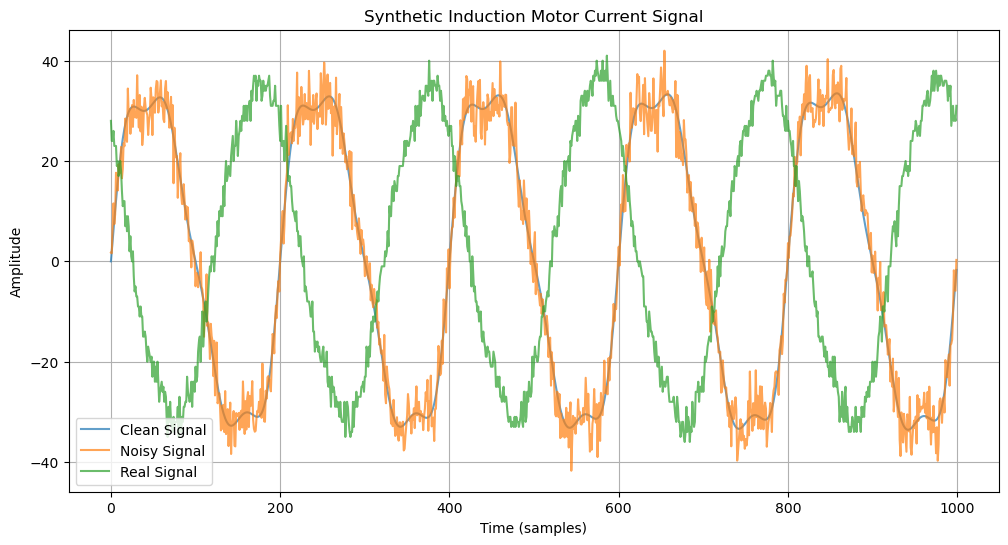

In [4]:
clean_signal, noisy_signal = generate_induction_motor_signal(
    signal_length=signal_length,
    sampling_rate=sampling_rate,
    fundamental_freq=50,
    noise_scale=0.1,
    add_harmonics=True,
    add_spikes=False,
    add_noise=True,
    add_modulation=True 
)

# Read real data
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

# Plot the signals
plt.figure(figsize=(12, 6))
plt.plot(clean_signal[:1000] * 35, label='Clean Signal', alpha=0.7)
plt.plot(noisy_signal[:1000] * 35, label='Noisy Signal', alpha=0.7)
plt.plot(df['Data'][:1000], label='Real Signal', alpha=0.7)
plt.title('Synthetic Induction Motor Current Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

In [5]:
segments = segment_signal(noisy_signal, segment_length=segment_length, step=step, apply_window=False)

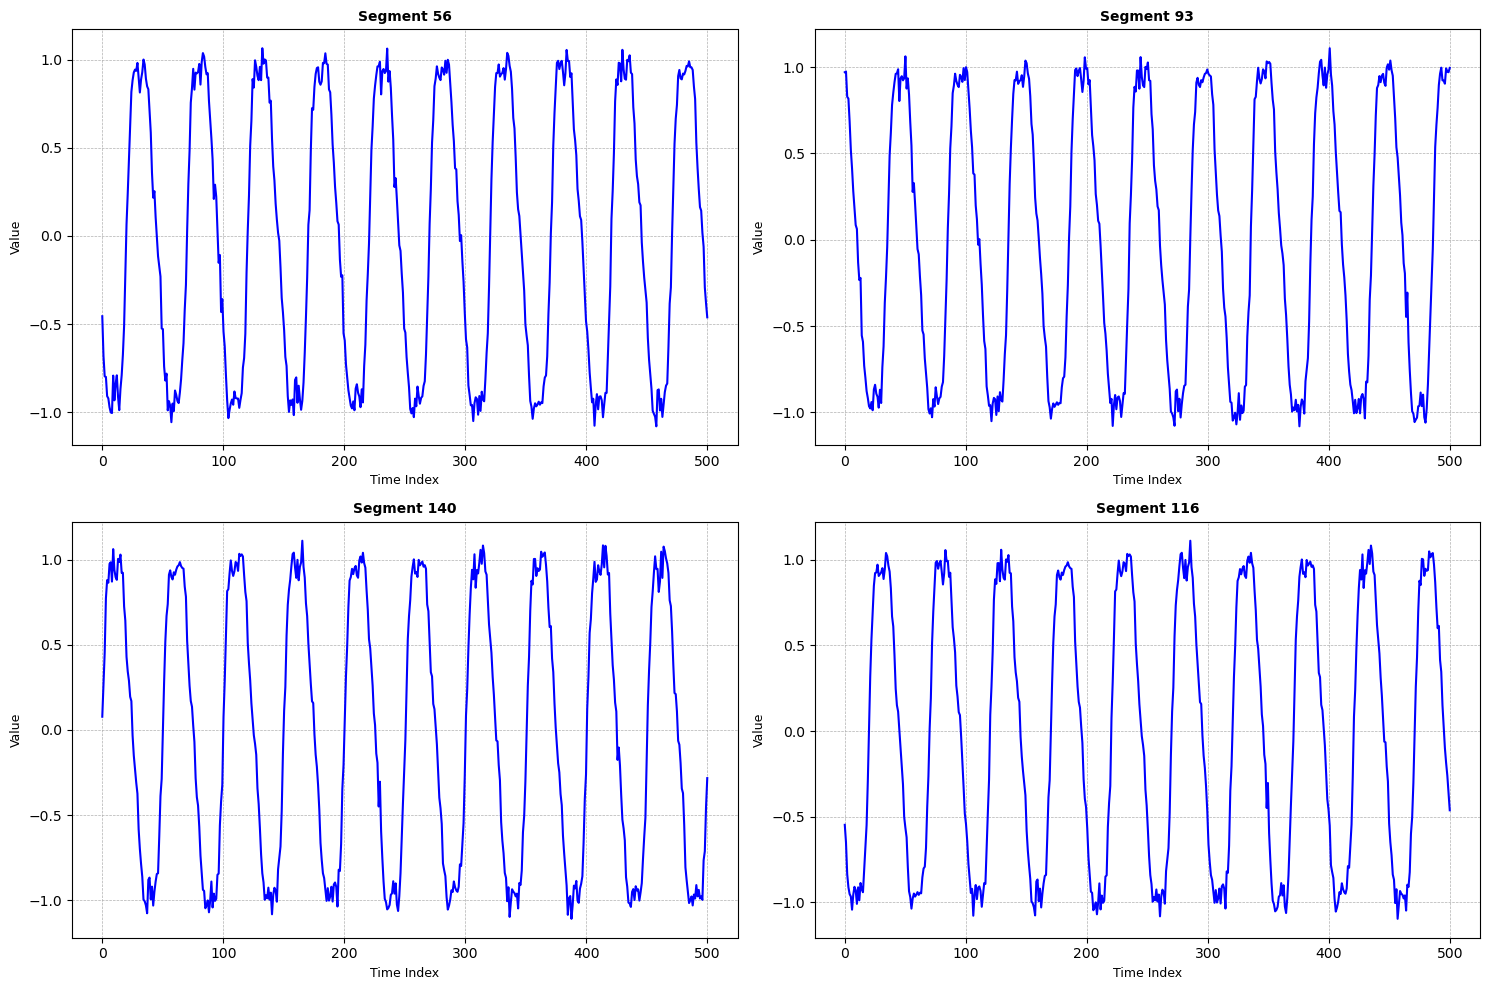

In [6]:
# Plot segments
plot_random_segments(segments, num_segments=4, max_points=500, axis_labels=('Time Index', 'Value'))

In [7]:
fft_segments, freqs = perform_fft_on_segments(segments, f_sampling=10000, db=True, cutoff_freq=250)

In [8]:
for i in range(fft_segments.shape[0]):
    fft_segments[i, :] = normalize_segment(fft_segments[i, :])[0]

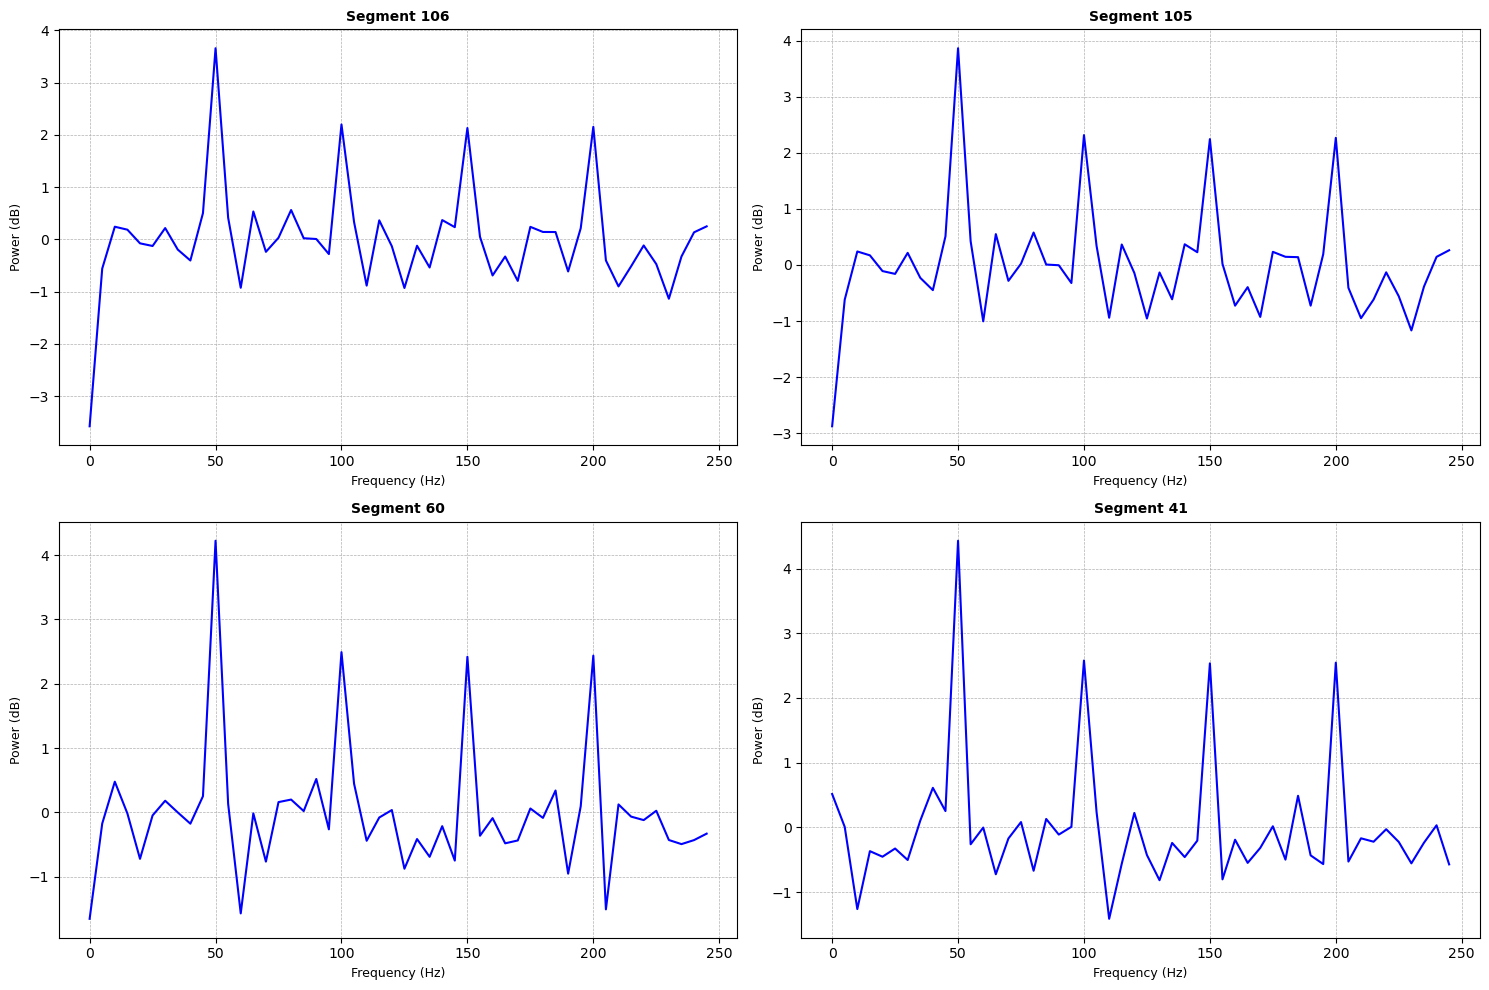

In [9]:
# Plot segments
plot_random_segments(fft_segments, num_segments=4, x_values=freqs)

## VAE

In [10]:
from src.models import VAE
from src.train import train_vae

In [11]:
def prepare_dataloader(segments_t, batch_size):
    segments = segments_t.copy()
    for i in range(segments.shape[0]):
        segments[i, :] = normalize_segment(segments[i, :])[0]

    segments_tensor = torch.tensor(segments, dtype=torch.float32)
    # Add channel dimension (expected by Conv1d layers)
    segments_tensor = segments_tensor.unsqueeze(1)  # Shape: [num_segments, 1, segment_length]
    dataset = TensorDataset(segments_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataloader


# Denoise the signal using the trained VAE
def denoise_signal(model, noisy_segments):
    model.eval()
    with torch.no_grad():
        # Convert segments to tensor and add channel dimension
        noisy_segments_tensor = torch.tensor(noisy_segments, dtype=torch.float32).unsqueeze(1)
        reconstructed_segments = model(noisy_segments_tensor.to('mps'))[0]
        return reconstructed_segments.cpu().numpy()


In [12]:
# Instantiate and train the VAE
epochs = 10
lr = 0.0001
latent_dim = 16
input_dim = segment_length
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

# Initialize model and optimizer
vae = VAE(input_dim=input_dim, latent_dim=latent_dim)
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

dataloader = prepare_dataloader(segments, batch_size=32)
train_vae(vae, dataloader, optimizer=optimizer, num_epochs=epochs, device=device)

Training:   0%|          | 0/50 [00:00<?, ?batch/s]

Epoch 1/10, Avg Loss: 698.81824
Epoch 2/10, Avg Loss: 687.60720
Epoch 3/10, Avg Loss: 676.88085
Epoch 4/10, Avg Loss: 662.65030
Epoch 5/10, Avg Loss: 653.97101
Epoch 6/10, Avg Loss: 645.71178
Epoch 7/10, Avg Loss: 636.12054
Epoch 8/10, Avg Loss: 629.42563
Epoch 9/10, Avg Loss: 619.10716
Epoch 10/10, Avg Loss: 610.04047
Final Average Loss: 610.0405


In [13]:
# Denoise the signal
denoised_segments = denoise_signal(vae, segments)


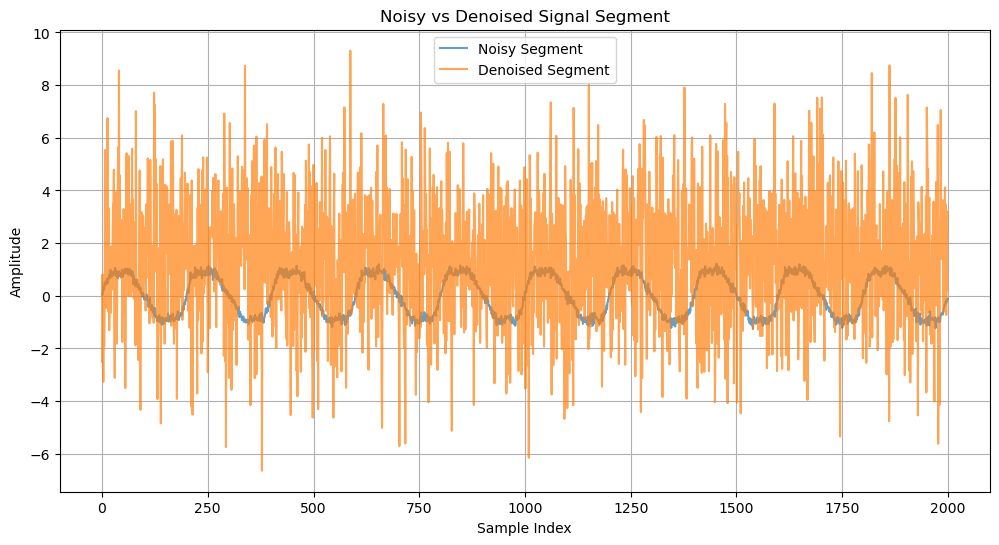

In [14]:

# Plot the original, noisy, and denoised signals
plt.figure(figsize=(12, 6))
plt.plot(segments[0], label="Noisy Segment", alpha=0.7)
plt.plot(denoised_segments.squeeze(1)[0], label="Denoised Segment", alpha=0.7)
plt.title("Noisy vs Denoised Signal Segment")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.show()